# Fashion MNIST

Fashion Mnist는 옷, 바지 등 10가지 종류의 의류로 구성된 데이터입니다. 이 데이터는 (28, 28) 크기로 구성되어 있으며 Training Set 6만장, Test Set 1만장으로 총합 7만장으로 이루어져 있습니다. Keras에서 dataset을 import 할 수 있고, 처음 import 시 다운로드 하는 과정이 추가됩니다.

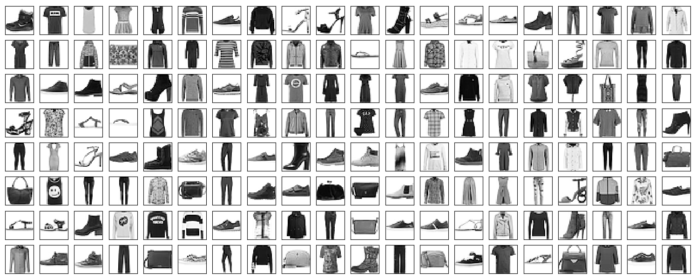


## 데이터 로드

In [ ]:
import tensorflow as tf

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 데이터 shape 확인

In [ ]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


### 이미지 출력
#### 5 x 5로 이미지 출력
#### cmap='gray_r'  

In [ ]:
import matplotlib.pyplot as plt

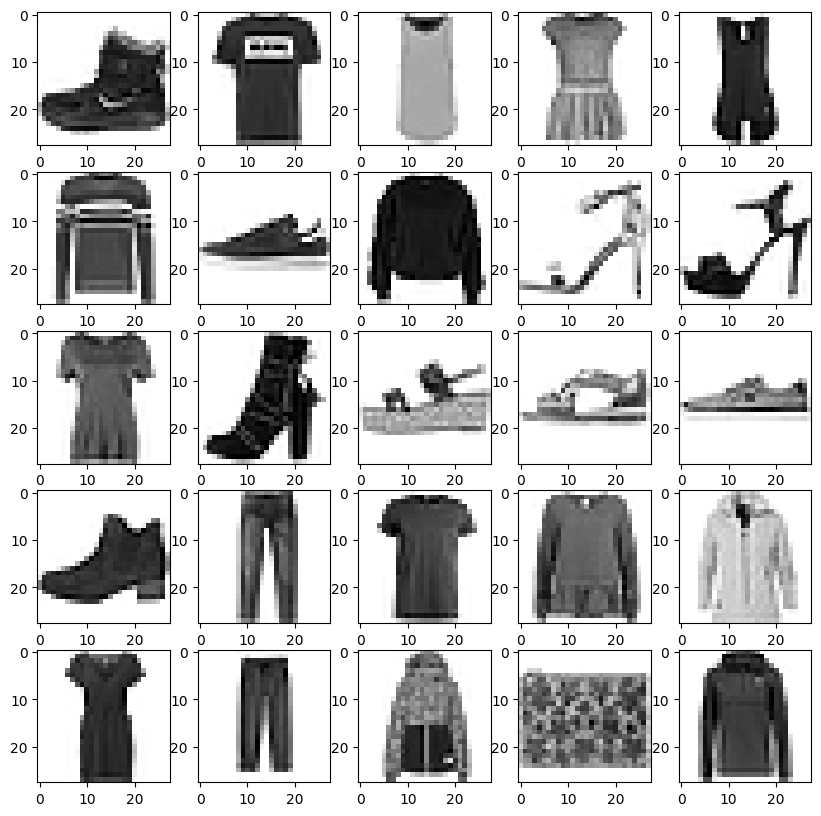

In [ ]:
fig, axs = plt.subplots(5,5, figsize=(10, 10))
for i in range(5):
  for j in range(5):
    axs[i, j].imshow(x_train[i*5+j], cmap='gray_r')
plt.show()


## class 확인

In [ ]:
items = {0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress',
         4:'Coat', 5:'Sandal', 6:'Shirt', 7:'Sneaker',
         8:'Bag', 9:'Ankel boot'}

In [ ]:
y_train[0:25]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5, 0, 9, 5, 5, 7, 9, 1, 0, 6, 4, 3, 1,
       4, 8, 4], dtype=uint8)

In [ ]:
print([items[i] for i in y_train[:25]])

['Ankel boot', 'T-shirt/top', 'T-shirt/top', 'Dress', 'T-shirt/top', 'Pullover', 'Sneaker', 'Pullover', 'Sandal', 'Sandal', 'T-shirt/top', 'Ankel boot', 'Sandal', 'Sandal', 'Sneaker', 'Ankel boot', 'Trouser', 'T-shirt/top', 'Shirt', 'Coat', 'Dress', 'Trouser', 'Coat', 'Bag', 'Coat']


In [ ]:
import numpy as np

In [ ]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [ ]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [ ]:
print([items[i] for i in np.unique(y_train)])

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankel boot']


## 검증데이터(validation data) 생성

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# train데이터의 20%를 검증데이터(val)로 빼기
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)

In [ ]:
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(48000, 28, 28) (48000,)
(12000, 28, 28) (12000,)
(10000, 28, 28) (10000,)


## one-hot encoding

In [ ]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_val = tf.keras.utils.to_categorical(y_val, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [ ]:
print(y_train.shape, y_val.shape, y_test.shape)

(48000, 10) (12000, 10) (10000, 10)


## 정규화(Normalization)

In [ ]:
x_train = x_train / 255
x_val = x_val / 255
x_test = x_test / 255

In [ ]:
print(x_val[0:10])

[[[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  ...
  [0.00784314 0.         0.43921569 ... 0.         0.         0.00392157]
  [0.00784314 0.         0.08235294 ... 0.         0.00392157 0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]]

 [[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  ...
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.         0.         ... 0.         0.         0.        ]]

 [[0.         0.         0.         ... 0.         0.         0.        ]
  [0.         0.      

## 직렬화

In [ ]:
x_train = x_train.reshape(-1, 28*28)
x_val = x_val.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

In [ ]:
print(x_train.shape, x_val.shape, x_test.shape)

(48000, 784) (12000, 784) (10000, 784)


## model 생성

In [ ]:
from tensorflow.keras import layers, models

In [ ]:
# 784-128-64-32-10
model = models.Sequential([
    layers.Dense(128, activation='sigmoid', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')  # y의 shape과 동일하게 10
])


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='categorical_crossentropy', metrics=['acc'])

## 학습

In [ ]:
history = model.fit(x_train, y_train, epochs=30, validation_data=(x_val, y_val))  # 학습하면서 검증

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - acc: 0.7903 - loss: 0.5777 - val_acc: 0.8215 - val_loss: 0.4798
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - acc: 0.8497 - loss: 0.4103 - val_acc: 0.8580 - val_loss: 0.3808
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.8635 - loss: 0.3696 - val_acc: 0.8607 - val_loss: 0.3748
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8745 - loss: 0.3447 - val_acc: 0.8715 - val_loss: 0.3484
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8804 - loss: 0.3251 - val_acc: 0.8727 - val_loss: 0.3627
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.8859 - loss: 0.3120 - val_acc: 0.8780 - val_loss: 0.3486
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8900 - loss: 0.2994 - val_acc: 0.8788 - val_loss: 0.3348
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.8938 - loss: 0.2917 - val_acc: 0.8843 - val_loss: 0.3304
Epoch 9/30
1500/1500 ━━━━━━━━━━━━━━━━━━━

## 학습곡선

In [ ]:
history.history

{'acc': [0.7902708053588867,
  0.8497291803359985,
  0.8634791374206543,
  0.8744999766349792,
  0.8804374933242798,
  0.885854184627533,
  0.8899583220481873,
  0.893791675567627,
  0.8974999785423279,
  0.8994583487510681,
  0.901520848274231,
  0.9031041860580444,
  0.9064375162124634,
  0.9084166884422302,
  0.9091041684150696,
  0.9119374752044678,
  0.9127083420753479,
  0.9146249890327454,
  0.9159374833106995,
  0.917229175567627,
  0.9186458587646484,
  0.9181666374206543,
  0.918874979019165,
  0.9194999933242798,
  0.9221041798591614,
  0.9229166507720947,
  0.9235208630561829,
  0.9265000224113464,
  0.9276666641235352,
  0.9270416498184204],
 'loss': [0.577709436416626,
  0.4103116989135742,
  0.36958539485931396,
  0.34473133087158203,
  0.325082004070282,
  0.3120341897010803,
  0.2993561029434204,
  0.29165512323379517,
  0.2813429832458496,
  0.2755388617515564,
  0.26767387986183167,
  0.2648206651210785,
  0.25782084465026855,
  0.25278323888778687,
  0.2491473406553

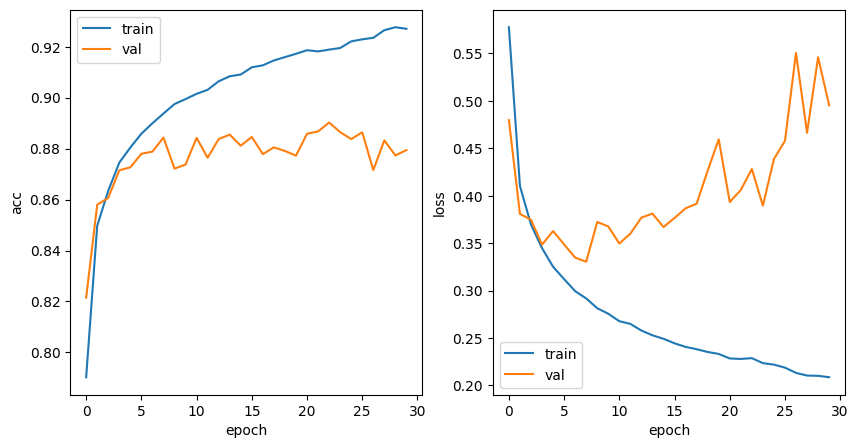

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.legend(['train', 'val'])
plt.xlabel('epoch')
plt.ylabel('acc')

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'val'])
plt.xlabel('epoch')
plt.ylabel('loss')

plt.show()

## 과대적합(Over fitting)/과소적합(Under fitting)

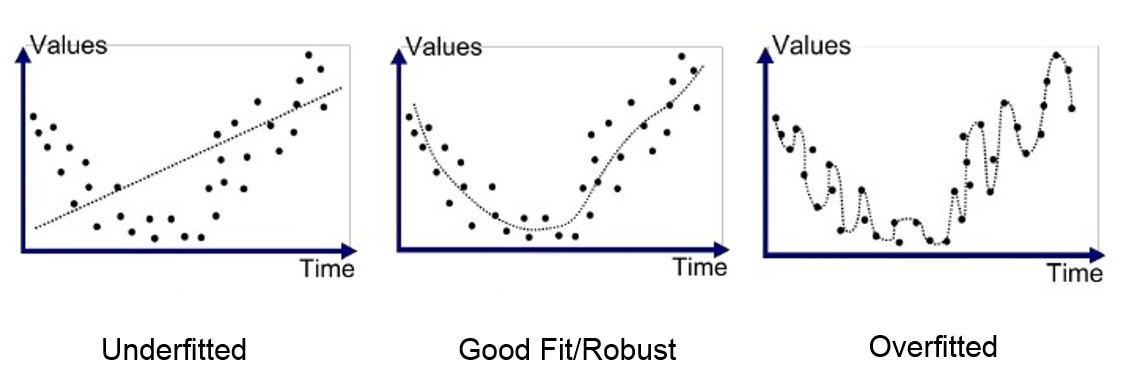

In [ ]:
model1 = models.Sequential([
    layers.Dense(128, activation='sigmoid', input_shape=(784,)),
    layers.Dropout(0.3),  # 30% 뉴런을 무작위로 꺼버림 - Overfitted를 막기 위해서
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')  # y의 shape과 동일하게 10
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model1.compile(loss='categorical_crossentropy', metrics=['acc'])

In [ ]:
history1 = model1.fit(x_train, y_train, epochs=30, validation_data=(x_val, y_val))

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - acc: 0.7682 - loss: 0.6298 - val_acc: 0.8344 - val_loss: 0.4481
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8330 - loss: 0.4593 - val_acc: 0.8450 - val_loss: 0.4233
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.8465 - loss: 0.4211 - val_acc: 0.8607 - val_loss: 0.3780
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.8561 - loss: 0.3960 - val_acc: 0.8701 - val_loss: 0.3600
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.8615 - loss: 0.3799 - val_acc: 0.8741 - val_loss: 0.3524
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - acc: 0.8675 - loss: 0.3686 - val_acc: 0.8724 - val_loss: 0.3514
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8707 - loss: 0.3615 - val_acc: 0.8655 - val_loss: 0.3620
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc: 0.8717 - loss: 0.3505 - val_acc: 0.8787 - val_loss: 0.3385
Epoch 9/30
1500/1500 ━━━━━━━━━━━━━━━━━━━

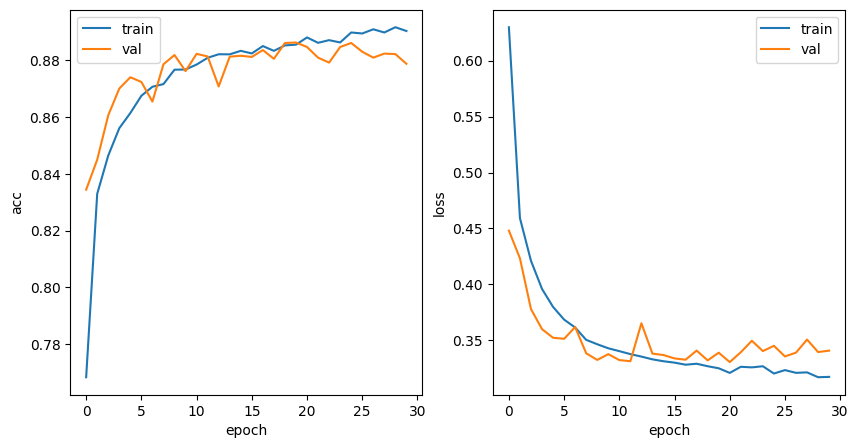

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history1.history['acc'])
plt.plot(history1.history['val_acc'])
plt.legend(['train', 'val'])
plt.xlabel('epoch')
plt.ylabel('acc')

plt.subplot(1,2,2)
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.legend(['train', 'val'])
plt.xlabel('epoch')
plt.ylabel('loss')

plt.show()

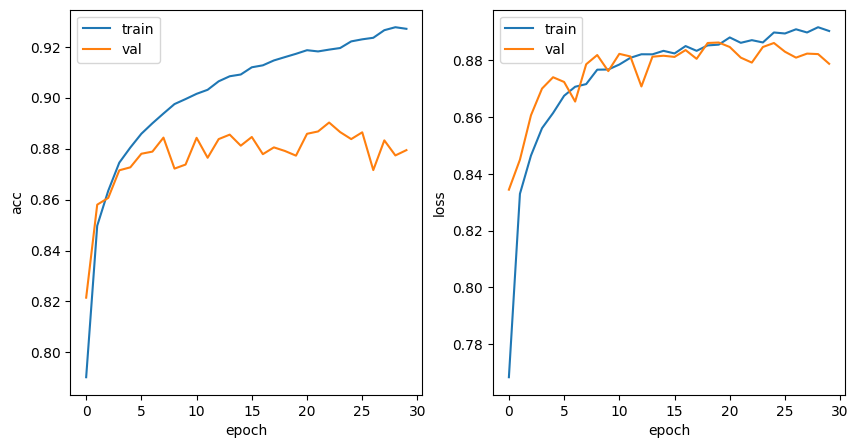

In [ ]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.legend(['train', 'val'])
plt.xlabel('epoch')
plt.ylabel('acc')

plt.subplot(1,2,2)
plt.plot(history1.history['acc'])
plt.plot(history1.history['val_acc'])
plt.legend(['train', 'val'])
plt.xlabel('epoch')
plt.ylabel('loss')

plt.show()

In [ ]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - acc: 0.8738 - loss: 0.5256


[0.525597870349884, 0.8737999796867371]

In [ ]:
model1.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.8728 - loss: 0.3673


[0.3672877848148346, 0.8727999925613403]

In [ ]:
model.save('fmnist_nn.keras')

In [ ]:
model3 = models.load_model('fmnist_nn.keras')

In [ ]:
model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,148 (434.18 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)